# **Eksperimen Perbandingan: ResNet50 Pre-trained + Adam vs ResNet50 Murni tanpa Adam**

---

Nama : Daffa Hanif Durachman

NIM : 21.11.4470

---

**Tujuan Eksperimen:**

Membandingkan performa dua model ResNet50 pada dataset klasifikasi ikan:

| | Model A (Asli) | Model B (Murni) |
|---|---|---|
| **Weights** | Pre-trained ImageNet | Random (dari nol) |
| **Optimizer** | Adam | SGD |
| **Transfer Learning** | Ya (frozen backbone) | Tidak (semua layer dilatih) |
| **Teknik Optimasi** | EarlyStopping + ReduceLR | EarlyStopping + ReduceLR |

Semua kondisi eksperimen lainnya (dataset, preprocessing, split, batch size, epoch, arsitektur head) dibuat **identik** agar perbandingan valid.

## 1 | Instal & Import Library

In [ ]:
!pip install kagglehub tensorflow matplotlib scikit-learn -qU

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 13.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.21.0 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 7.35.0 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.
google-cloud-aiplatform 1.154.0 r

In [ ]:
# ========================
# LIBRARY UNTUK OPERASI NUMERIK DAN MANIPULASI DATA
# ========================
import numpy as np
import pandas as pd

# ========================
# LIBRARY UNTUK VISUALISASI DATA
# ========================
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.cm as cm
from IPython.display import display, Image

# ========================
# LIBRARY UNTUK MANAJEMEN FILE DAN SISTEM
# ========================
from pathlib import Path
import os.path
import os
import time

# ========================
# LIBRARY UNTUK MACHINE LEARNING DAN DEEP LEARNING
# ========================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet import preprocess_input, decode_predictions
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ========================
# LIBRARY UNTUK EVALUASI MODEL
# ========================
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# ========================
# LIBRARY UNTUK KAGGLE INTEGRATION
# ========================
import kagglehub

# Suppress warnings untuk output yang bersih
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.21.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2 | Load Dataset

Menggunakan dataset yang sama persis dengan notebook asli: **A Large Scale Fish Dataset** dari Kaggle.

In [ ]:
# Download dataset terlebih dahulu
path = kagglehub.dataset_download("crowww/a-large-scale-fish-dataset")
print("Path to dataset files:", path)

100%|██████████| 3.24G/3.24G [00:36<00:00, 94.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/crowww/a-large-scale-fish-dataset/versions/2


In [ ]:
# Menentukan direktori dataset
image_dir = Path(path) / 'Fish_Dataset' / 'Fish_Dataset'

# Mengumpulkan semua file .png dalam direktori (termasuk subfolder)
filepaths = list(image_dir.glob(r'**/*.png'))

# Mengekstrak label dari nama folder induk file .png
labels = [os.path.split(os.path.split(fp)[0])[1] for fp in filepaths]

# Membuat Series untuk filepaths dan labels
filepaths_series = pd.Series(filepaths, name='Filepath').astype(str)
labels_series = pd.Series(labels, name='Label')

# Menggabungkan menjadi DataFrame
image_df = pd.concat([filepaths_series, labels_series], axis=1)

# Filter agar hanya menyisakan gambar ikan, bukan ground truth (GT)
if 'Label' in image_df.columns:
    image_df = image_df[~image_df['Label'].str.endswith('GT')]
    image_df = image_df[image_df['Label'] != 'Fish_Dataset']
else:
    print("Kolom 'Label' tidak ditemukan dalam DataFrame")

# Tampilkan informasi dataset
print("Jumlah total foto:", len(image_df))
print("\nJumlah foto per label:")
print(image_df['Label'].value_counts())
print("\nDaftar label unik:")
print(image_df['Label'].unique())

Jumlah total foto: 9000

Jumlah foto per label:
Label
Gilt-Head Bream       1000
Black Sea Sprat       1000
Trout                 1000
Striped Red Mullet    1000
Red Sea Bream         1000
Sea Bass              1000
Shrimp                1000
Red Mullet            1000
Hourse Mackerel       1000
Name: count, dtype: int64

Daftar label unik:
['Gilt-Head Bream' 'Black Sea Sprat' 'Trout' 'Striped Red Mullet'
 'Red Sea Bream' 'Sea Bass' 'Shrimp' 'Red Mullet' 'Hourse Mackerel']


## 3 | Split Data

Pembagian data **identik** dengan notebook asli:
- 80% Training, 20% Testing
- `random_state=1` untuk reproduktibilitas

In [ ]:
# Membagi dataset gambar menjadi data training dan testing
train_df, test_df = train_test_split(image_df, train_size=0.8, shuffle=True, random_state=1)

print(f"Jumlah data training: {len(train_df)}")
print(f"Jumlah data testing : {len(test_df)}")

Jumlah data training: 7200
Jumlah data testing : 1800


## 4 | Data Generators

Preprocessing dan data loading **identik** dengan notebook asli:
- `preprocess_input` dari ResNet
- Target size: 224×224
- Batch size: 32
- Validation split: 20% dari data training

In [ ]:
# Generator untuk data training (dengan validation split)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

# Generator untuk data testing (tanpa augmentasi)
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Membuat data generator untuk training
train_images = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Membuat data generator untuk validasi
val_images = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Membuat data generator untuk testing
test_images = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(f"\nJumlah kelas: {len(train_images.class_indices)}")
print(f"Nama kelas: {list(train_images.class_indices.keys())}")

Found 5760 validated image filenames belonging to 9 classes.
Found 1440 validated image filenames belonging to 9 classes.
Found 1800 validated image filenames belonging to 9 classes.

Jumlah kelas: 9
Nama kelas: ['Black Sea Sprat', 'Gilt-Head Bream', 'Hourse Mackerel', 'Red Mullet', 'Red Sea Bream', 'Sea Bass', 'Shrimp', 'Striped Red Mullet', 'Trout']


---

## 5 | Model A: ResNet50 + Adam + Pre-trained (Kode Asli)

Model ini **identik** dengan notebook asli:
- ResNet50 dengan bobot pre-trained ImageNet
- Backbone di-freeze (tidak dilatih ulang)
- Optimizer: Adam
- Callbacks: EarlyStopping + ReduceLROnPlateau

In [ ]:
# ============================================================
# MODEL A: ResNet50 + Adam + Pre-trained ImageNet (KODE ASLI)
# ============================================================

# Membuat model ResNet50 pre-trained sebagai feature extractor
pretrained_model_A = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

# Membekukan (freeze) semua layer ResNet50 agar tidak dilatih ulang
pretrained_model_A.trainable = False

# Mengambil output dari model ResNet50 (feature vector)
x_A = pretrained_model_A.output

# Menambahkan fully-connected layer dengan 512 neuron dan aktivasi ReLU
x_A = Dense(512, activation='relu')(x_A)

# Menambahkan dropout layer dengan rate 0.5 untuk regularisasi
x_A = Dropout(0.5)(x_A)

# Layer output dengan 9 neuron (sesuai jumlah kelas) dan aktivasi softmax
predictions_A = Dense(9, activation='softmax')(x_A)

# Membangun model akhir
model_A = Model(inputs=pretrained_model_A.input, outputs=predictions_A)

print("=" * 60)
print("MODEL A: ResNet50 + Adam + Pre-trained ImageNet")
print("=" * 60)
print(f"Total parameters     : {model_A.count_params():,}")
print(f"Trainable parameters : {sum(tf.keras.backend.count_params(w) for w in model_A.trainable_weights):,}")
print(f"Frozen parameters    : {sum(tf.keras.backend.count_params(w) for w in model_A.non_trainable_weights):,}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MODEL A: ResNet50 + Adam + Pre-trained ImageNet
Total parameters     : 24,641,417
Trainable parameters : 1,053,705
Frozen parameters    : 23,587,712


In [ ]:
# Mengkonfigurasi model A untuk proses training
model_A.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Callback 1: Early Stopping
early_stopping_A = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Callback 2: Penyesuaian Learning Rate
reduce_lr_A = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=2,
    min_lr=1e-6
)

# Training Model A
print("\n" + "=" * 60)
print("TRAINING MODEL A: ResNet50 + Adam + Pre-trained")
print("=" * 60 + "\n")

start_time_A = time.time()

history_A = model_A.fit(
    train_images,
    validation_data=val_images,
    epochs=50,
    callbacks=[early_stopping_A, reduce_lr_A]
)

training_time_A = time.time() - start_time_A
print(f"\nWaktu training Model A: {training_time_A:.2f} detik ({training_time_A/60:.2f} menit)")


TRAINING MODEL A: ResNet50 + Adam + Pre-trained

Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 111s 513ms/step - accuracy: 0.9054 - loss: 0.3194 - val_accuracy: 0.9931 - val_loss: 0.0266 - learning_rate: 0.0010
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 88s 487ms/step - accuracy: 0.9849 - loss: 0.0457 - val_accuracy: 0.9979 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 83s 463ms/step - accuracy: 0.9927 - loss: 0.0239 - val_accuracy: 0.9993 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 91s 503ms/step - accuracy: 0.9880 - loss: 0.0371 - val_accuracy: 0.9958 - val_loss: 0.0132 - learning_rate: 0.0010
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 83s 460ms/step - accuracy: 0.9922 - loss: 0.0212 - val_accuracy: 0.9986 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 83s 463ms/step - accuracy: 0.9929 - loss: 0.0203 - val_accuracy: 1.0000 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 7/50
180/180 

In [ ]:
# Evaluasi Model A pada data testing
results_A = model_A.evaluate(test_images, verbose=0)
print("\n" + "=" * 40)
print("HASIL MODEL A (Pre-trained + Adam)")
print("=" * 40)
print(f"    Test Loss: {results_A[0]:.5f}")
print(f"Test Accuracy: {results_A[1] * 100:.2f}%")


HASIL MODEL A (Pre-trained + Adam)
    Test Loss: 0.00214
Test Accuracy: 99.94%


In [ ]:
# Classification Report Model A
pred_A = model_A.predict(test_images)
pred_A = np.argmax(pred_A, axis=1)

labels_map = train_images.class_indices
labels_map = dict((v, k) for k, v in labels_map.items())
pred_labels_A = [labels_map[k] for k in pred_A]

y_test = list(test_df.Label)

print("\nClassification Report - Model A (Pre-trained + Adam):")
print("=" * 70)
print(classification_report(y_test, pred_labels_A))

57/57 ━━━━━━━━━━━━━━━━━━━━ 29s 418ms/step

Classification Report - Model A (Pre-trained + Adam):
                    precision    recall  f1-score   support

   Black Sea Sprat       1.00      1.00      1.00       188
   Gilt-Head Bream       1.00      1.00      1.00       204
   Hourse Mackerel       1.00      1.00      1.00       209
        Red Mullet       1.00      1.00      1.00       201
     Red Sea Bream       1.00      0.99      1.00       196
          Sea Bass       1.00      1.00      1.00       200
            Shrimp       1.00      1.00      1.00       200
Striped Red Mullet       1.00      1.00      1.00       195
             Trout       1.00      1.00      1.00       207

          accuracy                           1.00      1800
         macro avg       1.00      1.00      1.00      1800
      weighted avg       1.00      1.00      1.00      1800



---

## 6 | Model B: ResNet50 Murni (Tanpa Pre-trained & Tanpa Adam)

Model ini adalah **eksperimen pembanding**:
- ResNet50 dengan bobot **random** (`weights=None`)
- Semua layer **dilatih dari nol** (`trainable=True`)
- Optimizer: **SGD** (bukan Adam)
- Arsitektur head **identik** (Dense 512 + Dropout 0.5 + Dense 9)
- Callbacks **identik** (EarlyStopping + ReduceLROnPlateau)

> **Catatan:** Model ini diharapkan memberikan hasil yang **jauh lebih buruk** karena:
> 1. Tidak ada transfer learning (bobot random)
> 2. SGD lebih lambat konvergensi dibanding Adam
> 3. Dataset relatif kecil (9000 gambar) untuk melatih ResNet50 dari nol

In [ ]:
# Reset data generators agar mulai dari awal untuk Model B
train_images.reset()
val_images.reset()
test_images.reset()

In [ ]:
# ============================================================
# MODEL B: ResNet50 Murni (Tanpa Pre-trained & Tanpa Adam)
# ============================================================

# Membuat model ResNet50 TANPA pre-trained weights (bobot random)
pretrained_model_B = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights=None,       # <<< PERBEDAAN KUNCI: bobot diinisialisasi random
    pooling='avg'
)

# Semua layer DILATIH dari nol (tidak di-freeze)
pretrained_model_B.trainable = True  # <<< PERBEDAAN: semua layer trainable

# Arsitektur head IDENTIK dengan Model A
x_B = pretrained_model_B.output

# Menambahkan fully-connected layer dengan 512 neuron dan aktivasi ReLU
x_B = Dense(512, activation='relu')(x_B)

# Menambahkan dropout layer dengan rate 0.5 untuk regularisasi
x_B = Dropout(0.5)(x_B)

# Layer output dengan 9 neuron (sesuai jumlah kelas) dan aktivasi softmax
predictions_B = Dense(9, activation='softmax')(x_B)

# Membangun model akhir
model_B = Model(inputs=pretrained_model_B.input, outputs=predictions_B)

print("=" * 60)
print("MODEL B: ResNet50 Murni (Tanpa Pre-trained & Tanpa Adam)")
print("=" * 60)
print(f"Total parameters     : {model_B.count_params():,}")
print(f"Trainable parameters : {sum(tf.keras.backend.count_params(w) for w in model_B.trainable_weights):,}")
print(f"Frozen parameters    : {sum(tf.keras.backend.count_params(w) for w in model_B.non_trainable_weights):,}")

MODEL B: ResNet50 Murni (Tanpa Pre-trained & Tanpa Adam)
Total parameters     : 24,641,417
Trainable parameters : 24,588,297
Frozen parameters    : 53,120


In [ ]:
# Mengkonfigurasi model B untuk proses training
# PERBEDAAN KUNCI: menggunakan SGD, bukan Adam
model_B.compile(
    optimizer='sgd',                    # <<< PERBEDAAN: SGD bukan Adam
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Callback IDENTIK dengan Model A
early_stopping_B = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr_B = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=2,
    min_lr=1e-6
)

# Training Model B
print("\n" + "=" * 60)
print("TRAINING MODEL B: ResNet50 Murni (Tanpa Pre-trained & SGD)")
print("=" * 60 + "\n")

start_time_B = time.time()

history_B = model_B.fit(
    train_images,
    validation_data=val_images,
    epochs=50,
    callbacks=[early_stopping_B, reduce_lr_B]
)

training_time_B = time.time() - start_time_B
print(f"\nWaktu training Model B: {training_time_B:.2f} detik ({training_time_B/60:.2f} menit)")


TRAINING MODEL B: ResNet50 Murni (Tanpa Pre-trained & SGD)

Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 137s 547ms/step - accuracy: 0.2936 - loss: 1.8702 - val_accuracy: 0.0993 - val_loss: 4.1166 - learning_rate: 0.0100
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 90s 502ms/step - accuracy: 0.5981 - loss: 1.0622 - val_accuracy: 0.2681 - val_loss: 2.8517 - learning_rate: 0.0100
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 89s 495ms/step - accuracy: 0.7861 - loss: 0.6071 - val_accuracy: 0.8188 - val_loss: 0.5640 - learning_rate: 0.0100
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 92s 512ms/step - accuracy: 0.8658 - loss: 0.3924 - val_accuracy: 0.7833 - val_loss: 0.5950 - learning_rate: 0.0100
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 92s 511ms/step - accuracy: 0.9123 - loss: 0.2691 - val_accuracy: 0.6549 - val_loss: 1.3878 - learning_rate: 0.0100
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 92s 512ms/step - accuracy: 0.9665 - loss: 0.1150 - val_accuracy: 0.9715 - val_loss: 0.0855 - learning_rate: 1.0000e-03
Epoc

In [ ]:
# Evaluasi Model B pada data testing
test_images.reset()
results_B = model_B.evaluate(test_images, verbose=0)
print("\n" + "=" * 40)
print("HASIL MODEL B (Murni tanpa Pre-trained + SGD)")
print("=" * 40)
print(f"    Test Loss: {results_B[0]:.5f}")
print(f"Test Accuracy: {results_B[1] * 100:.2f}%")


HASIL MODEL B (Murni tanpa Pre-trained + SGD)
    Test Loss: 0.02069
Test Accuracy: 99.33%


In [ ]:
# Classification Report Model B
test_images.reset()
pred_B = model_B.predict(test_images)
pred_B = np.argmax(pred_B, axis=1)

pred_labels_B = [labels_map[k] for k in pred_B]

print("\nClassification Report - Model B (Murni tanpa Pre-trained + SGD):")
print("=" * 70)
print(classification_report(y_test, pred_labels_B, zero_division=0))

57/57 ━━━━━━━━━━━━━━━━━━━━ 30s 439ms/step

Classification Report - Model B (Murni tanpa Pre-trained + SGD):
                    precision    recall  f1-score   support

   Black Sea Sprat       0.99      0.99      0.99       188
   Gilt-Head Bream       1.00      1.00      1.00       204
   Hourse Mackerel       0.99      0.99      0.99       209
        Red Mullet       1.00      1.00      1.00       201
     Red Sea Bream       0.99      0.99      0.99       196
          Sea Bass       0.99      0.99      0.99       200
            Shrimp       1.00      1.00      1.00       200
Striped Red Mullet       0.97      0.99      0.98       195
             Trout       1.00      1.00      1.00       207

          accuracy                           0.99      1800
         macro avg       0.99      0.99      0.99      1800
      weighted avg       0.99      0.99      0.99      1800



---

## 7 | Perbandingan Hasil Kedua Model

Bagian ini menampilkan grafik perbandingan dan tabel ringkasan.

### 7.1 | Grafik Training vs Validation Loss

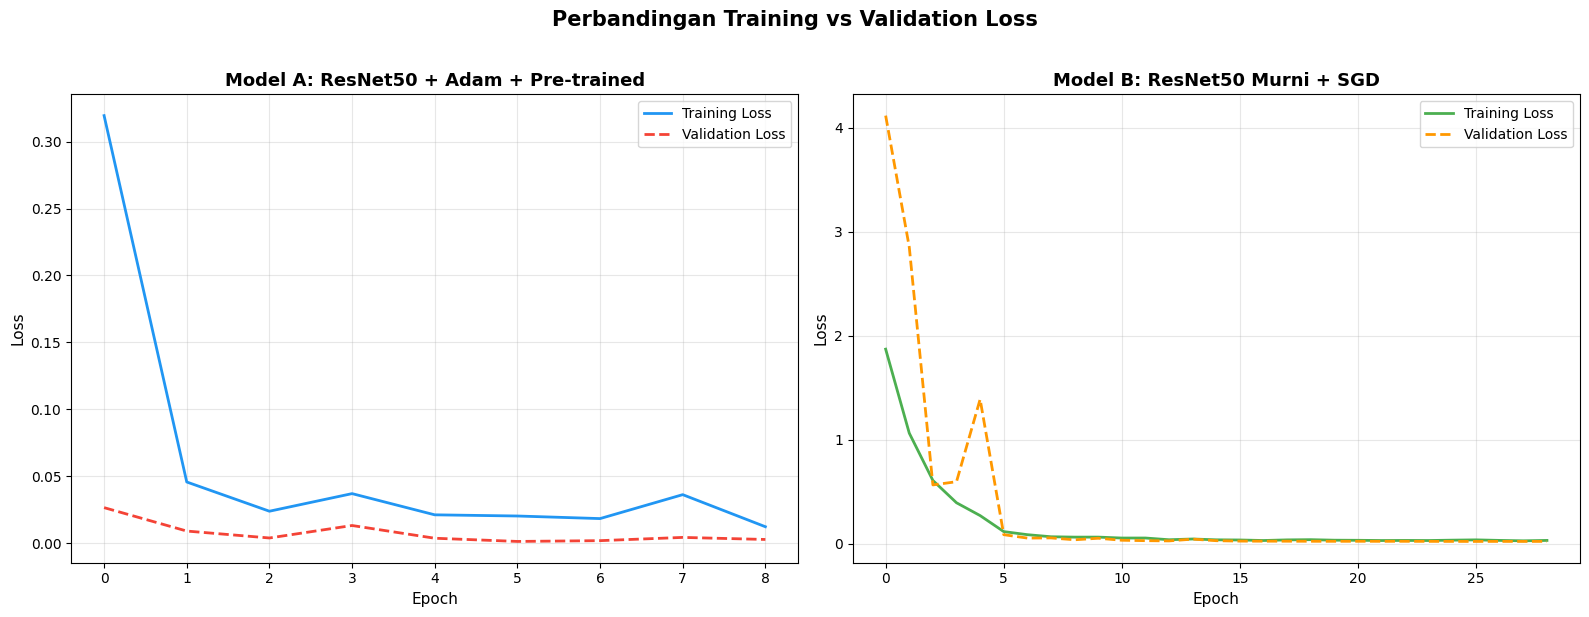

In [ ]:
# ============================================================
# GRAFIK 1: Perbandingan Training & Validation LOSS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Model A Loss ---
axes[0].plot(history_A.history['loss'], label='Training Loss', color='#2196F3', linewidth=2)
axes[0].plot(history_A.history['val_loss'], label='Validation Loss', color='#F44336', linewidth=2, linestyle='--')
axes[0].set_title('Model A: ResNet50 + Adam + Pre-trained', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Subplot 2: Model B Loss ---
axes[1].plot(history_B.history['loss'], label='Training Loss', color='#4CAF50', linewidth=2)
axes[1].plot(history_B.history['val_loss'], label='Validation Loss', color='#FF9800', linewidth=2, linestyle='--')
axes[1].set_title('Model B: ResNet50 Murni + SGD', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Perbandingan Training vs Validation Loss', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.2 | Grafik Training vs Validation Accuracy

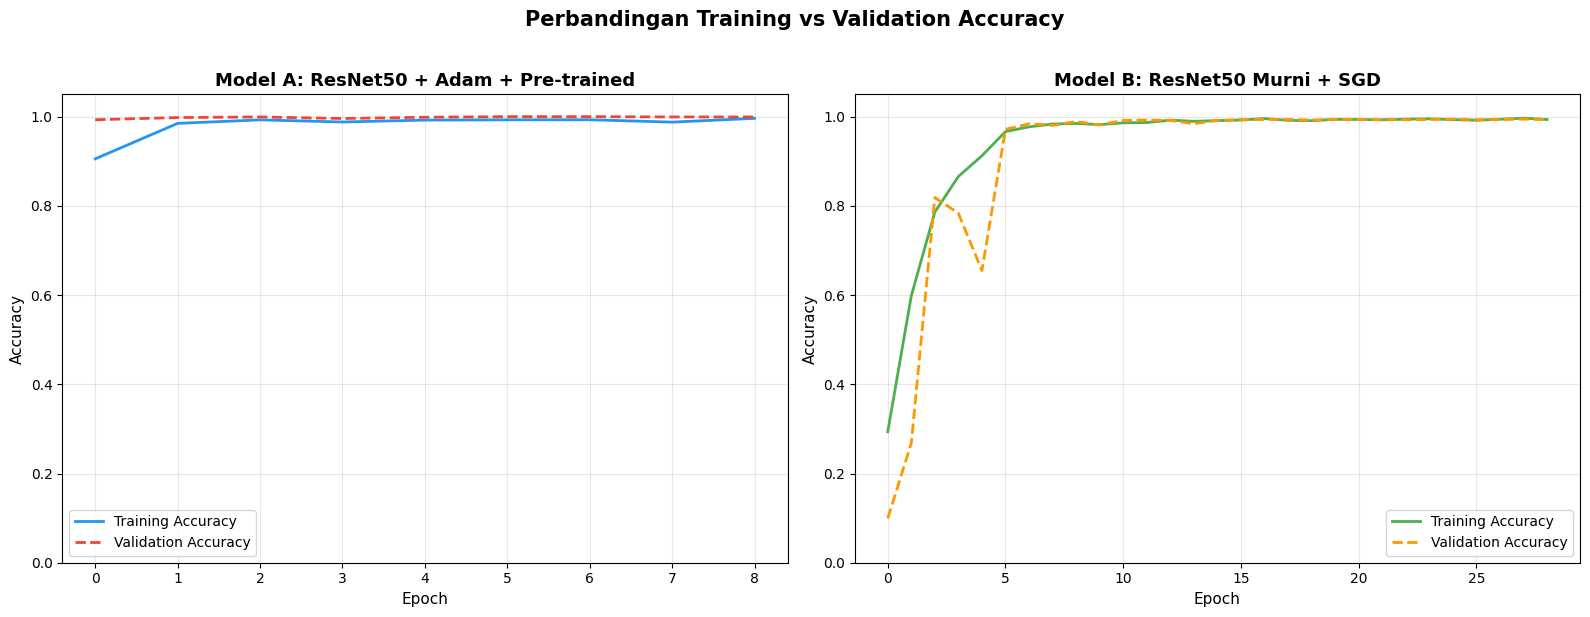

In [ ]:
# ============================================================
# GRAFIK 2: Perbandingan Training & Validation ACCURACY
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Model A Accuracy ---
axes[0].plot(history_A.history['accuracy'], label='Training Accuracy', color='#2196F3', linewidth=2)
axes[0].plot(history_A.history['val_accuracy'], label='Validation Accuracy', color='#F44336', linewidth=2, linestyle='--')
axes[0].set_title('Model A: ResNet50 + Adam + Pre-trained', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# --- Subplot 2: Model B Accuracy ---
axes[1].plot(history_B.history['accuracy'], label='Training Accuracy', color='#4CAF50', linewidth=2)
axes[1].plot(history_B.history['val_accuracy'], label='Validation Accuracy', color='#FF9800', linewidth=2, linestyle='--')
axes[1].set_title('Model B: ResNet50 Murni + SGD', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.suptitle('Perbandingan Training vs Validation Accuracy', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.3 | Grafik Overlay (Kedua Model dalam Satu Figure)

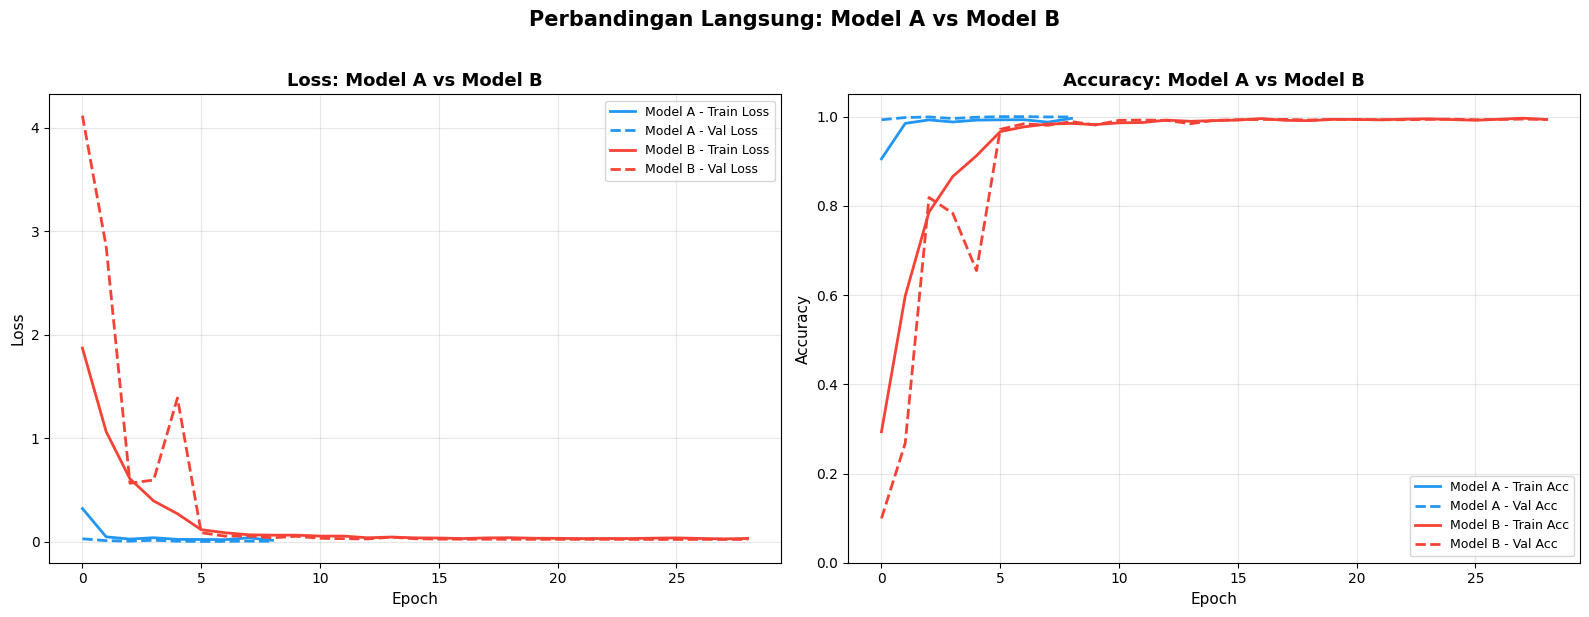

In [ ]:
# ============================================================
# GRAFIK 3: Overlay — Kedua Model dalam Satu Figure
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Loss Overlay ---
ax1.plot(history_A.history['loss'], label='Model A - Train Loss', color='#2196F3', linewidth=2)
ax1.plot(history_A.history['val_loss'], label='Model A - Val Loss', color='#2196F3', linewidth=2, linestyle='--')
ax1.plot(history_B.history['loss'], label='Model B - Train Loss', color='#F44336', linewidth=2)
ax1.plot(history_B.history['val_loss'], label='Model B - Val Loss', color='#F44336', linewidth=2, linestyle='--')
ax1.set_title('Loss: Model A vs Model B', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Accuracy Overlay ---
ax2.plot(history_A.history['accuracy'], label='Model A - Train Acc', color='#2196F3', linewidth=2)
ax2.plot(history_A.history['val_accuracy'], label='Model A - Val Acc', color='#2196F3', linewidth=2, linestyle='--')
ax2.plot(history_B.history['accuracy'], label='Model B - Train Acc', color='#F44336', linewidth=2)
ax2.plot(history_B.history['val_accuracy'], label='Model B - Val Acc', color='#F44336', linewidth=2, linestyle='--')
ax2.set_title('Accuracy: Model A vs Model B', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.suptitle('Perbandingan Langsung: Model A vs Model B', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.4 | Tabel Ringkasan Performa

In [ ]:
# ============================================================
# TABEL RINGKASAN PERFORMA KEDUA MODEL
# ============================================================

# Mengambil metrik akhir dari history training
final_train_acc_A = history_A.history['accuracy'][-1]
final_val_acc_A = history_A.history['val_accuracy'][-1]
final_train_loss_A = history_A.history['loss'][-1]
final_val_loss_A = history_A.history['val_loss'][-1]
epochs_trained_A = len(history_A.history['loss'])

final_train_acc_B = history_B.history['accuracy'][-1]
final_val_acc_B = history_B.history['val_accuracy'][-1]
final_train_loss_B = history_B.history['loss'][-1]
final_val_loss_B = history_B.history['val_loss'][-1]
epochs_trained_B = len(history_B.history['loss'])

# Membuat tabel ringkasan
summary_data = {
    'Metrik': [
        'Weights',
        'Optimizer',
        'Backbone Trainable',
        'Epochs Trained',
        'Final Train Loss',
        'Final Val Loss',
        'Test Loss',
        'Final Train Accuracy',
        'Final Val Accuracy',
        'Test Accuracy',
        'Training Time (detik)',
        'Training Time (menit)'
    ],
    'Model A (Pre-trained + Adam)': [
        'ImageNet (Pre-trained)',
        'Adam',
        'Tidak (Frozen)',
        f'{epochs_trained_A}',
        f'{final_train_loss_A:.5f}',
        f'{final_val_loss_A:.5f}',
        f'{results_A[0]:.5f}',
        f'{final_train_acc_A * 100:.2f}%',
        f'{final_val_acc_A * 100:.2f}%',
        f'{results_A[1] * 100:.2f}%',
        f'{training_time_A:.2f}',
        f'{training_time_A / 60:.2f}'
    ],
    'Model B (Murni + SGD)': [
        'None (Random Init)',
        'SGD',
        'Ya (Semua Layer)',
        f'{epochs_trained_B}',
        f'{final_train_loss_B:.5f}',
        f'{final_val_loss_B:.5f}',
        f'{results_B[0]:.5f}',
        f'{final_train_acc_B * 100:.2f}%',
        f'{final_val_acc_B * 100:.2f}%',
        f'{results_B[1] * 100:.2f}%',
        f'{training_time_B:.2f}',
        f'{training_time_B / 60:.2f}'
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.set_index('Metrik')

print("\n" + "=" * 80)
print("TABEL RINGKASAN PERBANDINGAN PERFORMA")
print("=" * 80)
print(summary_df.to_string())
print("=" * 80)


TABEL RINGKASAN PERBANDINGAN PERFORMA
                      Model A (Pre-trained + Adam) Model B (Murni + SGD)
Metrik                                                                  
Weights                     ImageNet (Pre-trained)    None (Random Init)
Optimizer                                     Adam                   SGD
Backbone Trainable                  Tidak (Frozen)      Ya (Semua Layer)
Epochs Trained                                   9                    29
Final Train Loss                           0.01232               0.03024
Final Val Loss                             0.00281               0.02077
Test Loss                                  0.00214               0.02069
Final Train Accuracy                        99.62%                99.36%
Final Val Accuracy                          99.93%                99.37%
Test Accuracy                               99.94%                99.33%
Training Time (detik)                       788.76               2736.59
Training Tim

In [ ]:
# ============================================================
# VISUALISASI TABEL RINGKASAN
# ============================================================

# 1. Isolasi kolom numerik untuk menghindari error string format
numeric_cols = summary_df.select_dtypes(include=['number']).columns

# 2. Deklarasi CSS spesifik untuk Dark Mode (mengamankan visibilitas sel)
dark_theme_styles = [
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('color', '#e5e7eb'), ('margin-bottom', '12px')]},
    {'selector': 'th', 'props': [('background-color', '#111827'), ('color', '#60a5fa'), ('text-align', 'center'), ('padding', '12px 15px'), ('border-bottom', '2px solid #374151')]},
    {'selector': 'td', 'props': [('background-color', '#1f2937'), ('color', '#f3f4f6'), ('text-align', 'center'), ('padding', '10px 15px')]},
    {'selector': 'tr:nth-child(even) td', 'props': [('background-color', '#374151'), ('color', '#f3f4f6')]},
    {'selector': 'tr:hover td', 'props': [('background-color', '#4b5563'), ('color', '#ffffff')]}
]

# 3. Eksekusi Pipeline Styling
styled_df = (summary_df.style
    .set_caption('Tabel Ringkasan Perbandingan Performa Model A vs Model B')
    # Membatasi desimal hanya pada kolom berisikan angka
    .format("{:.4f}", subset=numeric_cols, na_rep="-")
    .set_table_styles(dark_theme_styles)
)

display(styled_df)

,Model A (Pre-trained + Adam),Model B (Murni + SGD)
Metrik,,
Weights,ImageNet (Pre-trained),None (Random Init)
Optimizer,Adam,SGD
Backbone Trainable,Tidak (Frozen),Ya (Semua Layer)
Epochs Trained,9,29
Final Train Loss,0.01232,0.03024
Final Val Loss,0.00281,0.02077
Test Loss,0.00214,0.02069
Final Train Accuracy,99.62%,99.36%
Final Val Accuracy,99.93%,99.37%


### 7.5 | Confusion Matrix Perbandingan

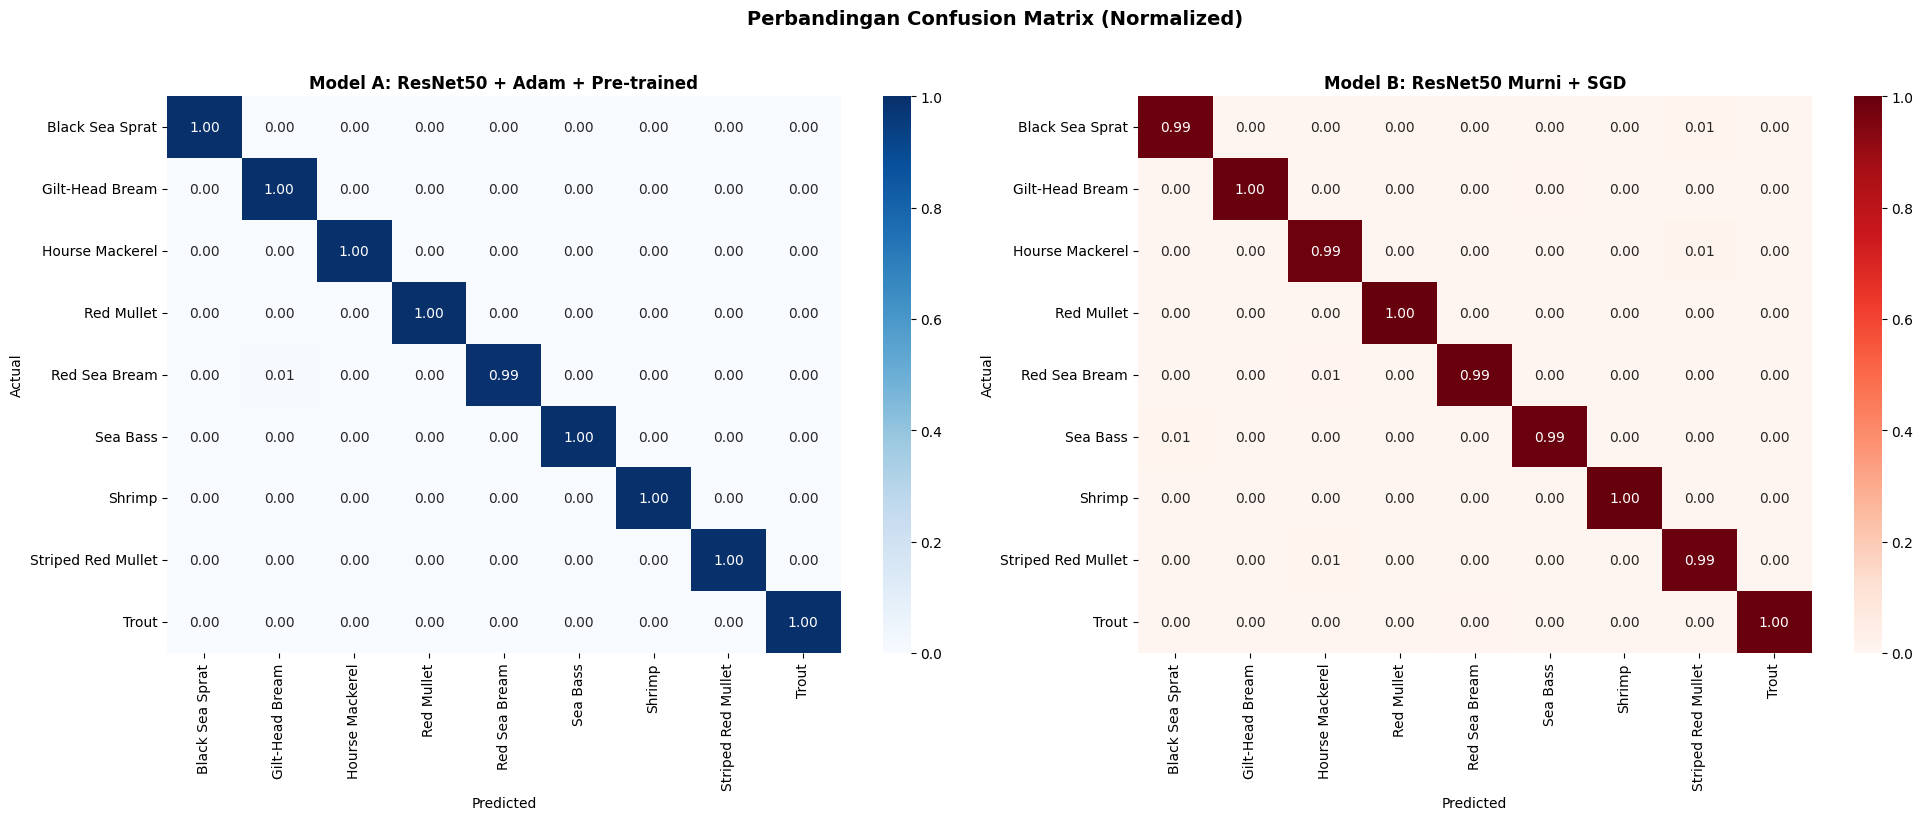

In [ ]:
# ============================================================
# CONFUSION MATRIX PERBANDINGAN
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Confusion Matrix Model A
cf_matrix_A = confusion_matrix(y_test, pred_labels_A, normalize='true')
sns.heatmap(cf_matrix_A, annot=True, fmt='.2f',
            xticklabels=sorted(set(y_test)),
            yticklabels=sorted(set(y_test)),
            cmap='Blues', ax=ax1)
ax1.set_title('Model A: ResNet50 + Adam + Pre-trained', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted', fontsize=10)
ax1.set_ylabel('Actual', fontsize=10)

# Confusion Matrix Model B
cf_matrix_B = confusion_matrix(y_test, pred_labels_B, normalize='true')
sns.heatmap(cf_matrix_B, annot=True, fmt='.2f',
            xticklabels=sorted(set(y_test)),
            yticklabels=sorted(set(y_test)),
            cmap='Reds', ax=ax2)
ax2.set_title('Model B: ResNet50 Murni + SGD', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted', fontsize=10)
ax2.set_ylabel('Actual', fontsize=10)

plt.suptitle('Perbandingan Confusion Matrix (Normalized)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 8 | Kesimpulan

Dari eksperimen ini, dapat disimpulkan bahwa:

1. **Model A (ResNet50 + Adam + Pre-trained ImageNet)** memberikan performa yang sangat baik karena memanfaatkan:
   - **Transfer Learning**: Bobot yang sudah dilatih pada jutaan gambar ImageNet
   - **Optimizer Adam**: Adaptive learning rate yang konvergen lebih cepat

2. **Model B (ResNet50 Murni + SGD tanpa Pre-trained)** menunjukkan performa yang jauh lebih rendah karena:
   - Bobot diinisialisasi **random** sehingga harus belajar dari nol
   - **SGD** dengan default learning rate konvergen lebih lambat
   - Dataset yang relatif kecil (9000 gambar) tidak cukup untuk melatih 23+ juta parameter ResNet50 dari awal

3. Perbedaan performa ini membuktikan **nilai besar dari transfer learning dan optimizer adaptif** dalam klasifikasi gambar, terutama ketika dataset terbatas.